# Sentiment Analysis Project
_Author: Lucy Wu_

_Date: 05/10/2025_

### 1. Setup & Imports
Import all necessary libraries for data handling, preprocessing, ML modeling, evaluation, and visualization.

In [1]:
import pandas as pd
import numpy as np
import time
import os
import tarfile
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support

nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /Users/lucywu/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/lucywu/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

### 2. Load and Explore Data
Load the Cornell Movie Review dataset from archive, extract reviews, and return them with their labels.

In [2]:
def load_data(archive_path):
    extracted_path = "../Data/txt_sentoken"
    if not os.path.exists(extracted_path):
        print("Extracting dataset...")
        with tarfile.open(archive_path, "r:gz") as tar:
            tar.extractall(path="../Data")

    data = []
    labels = []
    for label in ["pos", "neg"]:
        dir_path = os.path.join(extracted_path, label)
        for filename in os.listdir(dir_path):
            if filename.endswith(".txt"):
                with open(os.path.join(dir_path, filename), encoding="utf-8") as file:
                    data.append(file.read())
                    labels.append(label)
    print(f"Loaded {len(data)} comments.")
    print(f"Example comment:\n{data[1]}\n")
    return data, labels

data, labels = load_data("../Data/review_polarity.tar.gz")

Loaded 2000 comments.
Example comment:
plot : derek zoolander is a male model . 
he is also very dumb and impressionable . 
for that reason , he is secretly hired and trained ( so secret , that even he doesn't know about it ) by an underground fashion syndicate to assassinate the prime minister of malaysia , who wants to abolish child labor in his country . 
will zoolander fulfill the dirty deed ? 
will zoolander ever grace the world his new " look " ? 
is this a funny movie ? 
find out below . . . 
critique : there's a place in our world for " stupid comedies " . 
films which don't pretend to take themselves seriously , are based on idiotic premises and filled with dumb jokes . 
there's also a time for them and many would argue that this difficult period of our history , might be an ideal circumstance during which to " relax " by watching something so completely frivolous . 
well , if you're in the mood for some seriously mindless entertainment , ben stiller and his cast of many have 

### 3. Preprocessing
Clean and tokenize the text: lowercasing, removing punctuation, and removing stopwords

In [3]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stopwords.words('english')]
    return " ".join(tokens)

In [4]:
# Call the preprocess_text function on the data frame with all the reviews
df = pd.DataFrame({'review': data, 'label': labels})
df['review'] = df['review'].apply(preprocess_text)

### 4. Baseline Model (CountVectorizer + Naive Bayes Classifier)
Build and evaluate a simple model using bag-of-words and Naive Bayes.

In [5]:
def baseline_model(X_train, X_test, y_train, y_test):
    vectorizer = CountVectorizer()
    X_train_vec = vectorizer.fit_transform(X_train)
    X_test_vec = vectorizer.transform(X_test)

    model = MultinomialNB()
    model.fit(X_train_vec, y_train)
    preds = model.predict(X_test_vec)
    print("\nBaseline Model Results:")
    print(classification_report(y_test, preds))
    return model, vectorizer

In [6]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(df['review'], df['label'], test_size=0.2, random_state=50)
print("Calling baseline_model...")
model, vectorizer = baseline_model(X_train, X_test, y_train, y_test)

Calling baseline_model...

Baseline Model Results:
              precision    recall  f1-score   support

         neg       0.81      0.87      0.84       204
         pos       0.85      0.79      0.82       196

    accuracy                           0.83       400
   macro avg       0.83      0.83      0.83       400
weighted avg       0.83      0.83      0.83       400



### 5. Algorithm Comparison
Train and evaluate multiple machine learning models using the same feature set.

The models that are being compared includes:
* Logistic Regression
* Decision Tree
* Random Forest
* Naive Bayes

In [7]:
models = {
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "DecisionTree": DecisionTreeClassifier(),
    "RandomForest": RandomForestClassifier(),
    "NaiveBayes": MultinomialNB()
}

def compare_models(X_train, X_test, y_train, y_test, vectorizer):
    X_train_vec = vectorizer.fit_transform(X_train)
    X_test_vec = vectorizer.transform(X_test)

    for name, model in models.items():
        start = time.time()
        model.fit(X_train_vec, y_train)
        preds = model.predict(X_test_vec)
        end = time.time()
        print(f"\n{name} Results:")
        print(classification_report(y_test, preds))
        print(f"Training Time: {end - start:.2f} seconds")

In [8]:
print("\nCalling compare_models...")
compare_models(X_train, X_test, y_train, y_test, vectorizer)


Calling compare_models...

LogisticRegression Results:
              precision    recall  f1-score   support

         neg       0.87      0.86      0.86       204
         pos       0.86      0.86      0.86       196

    accuracy                           0.86       400
   macro avg       0.86      0.86      0.86       400
weighted avg       0.86      0.86      0.86       400

Training Time: 0.21 seconds

DecisionTree Results:
              precision    recall  f1-score   support

         neg       0.61      0.55      0.58       204
         pos       0.57      0.63      0.60       196

    accuracy                           0.59       400
   macro avg       0.59      0.59      0.59       400
weighted avg       0.59      0.59      0.59       400

Training Time: 0.52 seconds

RandomForest Results:
              precision    recall  f1-score   support

         neg       0.82      0.82      0.82       204
         pos       0.81      0.82      0.81       196

    accuracy            

### 6. Feature Engineering
Test multiple vectorization methods (Count vs. TF-IDF) to identify best feature representation.

In [9]:
def feature_engineering(X_train, X_test, y_train, y_test):
    strategies = {
        "CountVectorizer (default)": CountVectorizer(),
        "TfidfVectorizer (default)": TfidfVectorizer(),
        "Tfidf (min_df=5)": TfidfVectorizer(min_df=5),
        "Tfidf (max_df=0.8)": TfidfVectorizer(max_df=0.8),
        "Tfidf (max_features=1000)": TfidfVectorizer(max_features=1000),
        "Tfidf (remove low & high freq)": TfidfVectorizer(min_df=5, max_df=0.7)
    }

    for name, vec in strategies.items():
        start = time.time()
        X_train_vec = vec.fit_transform(X_train)
        X_test_vec = vec.transform(X_test)
        model = MultinomialNB()
        model.fit(X_train_vec, y_train)
        preds = model.predict(X_test_vec)
        end = time.time()
        print(f"\nFeature Strategy: {name}")
        print(f"Number of features: {len(vec.get_feature_names_out())}")
        print(f"Training Time: {end - start:.4f} seconds")
        print(classification_report(y_test, preds))

In [10]:
print("\nCalling feature_engineering...")
feature_engineering(X_train, X_test, y_train, y_test)


Calling feature_engineering...

Feature Strategy: CountVectorizer (default)
Number of features: 42382
Training Time: 0.2706 seconds
              precision    recall  f1-score   support

         neg       0.81      0.87      0.84       204
         pos       0.85      0.79      0.82       196

    accuracy                           0.83       400
   macro avg       0.83      0.83      0.83       400
weighted avg       0.83      0.83      0.83       400


Feature Strategy: TfidfVectorizer (default)
Number of features: 42382
Training Time: 0.2662 seconds
              precision    recall  f1-score   support

         neg       0.84      0.85      0.85       204
         pos       0.85      0.84      0.84       196

    accuracy                           0.84       400
   macro avg       0.85      0.84      0.84       400
weighted avg       0.85      0.84      0.84       400


Feature Strategy: Tfidf (min_df=5)
Number of features: 11657
Training Time: 0.3045 seconds
              precis

### 7. Improved System
After comparing the performance of all the different models, we implement an improved sentiment analysis system using a `LogisticRegression` model combined with `TfidfVectorizer` for feature extraction. The model is trained on the preprocessed training data and evaluated on the test set. Performance metrics such as precision, recall, and F1-score are calculated to assess the effectiveness of the improved system.

In [11]:
print("\nCalling improved system...")
improved_model = LogisticRegression(max_iter=1000)
tfidf = TfidfVectorizer()
X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)
improved_model.fit(X_train_vec, y_train)
preds = improved_model.predict(X_test_vec)
print("\nImproved System Results:")
print(classification_report(y_test, preds))


Calling improved system...

Improved System Results:
              precision    recall  f1-score   support

         neg       0.86      0.85      0.85       204
         pos       0.84      0.85      0.85       196

    accuracy                           0.85       400
   macro avg       0.85      0.85      0.85       400
weighted avg       0.85      0.85      0.85       400



### 8. Error Analysis
Display and analyze a few misclassified examples to understand weaknesses in the improved model.

In [12]:
def error_analysis(model, vectorizer, X_test, y_test):
    X_test_vec = vectorizer.transform(X_test)
    preds = model.predict(X_test_vec)
    misclassified = [(text, true, pred) for text, true, pred in zip(X_test, y_test, preds) if true != pred]
    for i, (text, true, pred) in enumerate(misclassified[:5]):
        print(f"\nExample {i+1}:")
        print(f"Actual: {true}, Predicted: {pred}\nMovie Review: {text}")

In [13]:
print("\nCalling error_analysis...")
error_analysis(improved_model, tfidf, X_test, y_test)


Calling error_analysis...

Example 1:
Actual: neg, Predicted: pos
Movie Review: people populate movie shallow selfabsorbed selfindulgent words perfectly mirror era well movie feature depicts story wellpublicized new york disco studio inplace anybody anybody went ogled photographed pampered difficulty written directed mark christopher script takes point view christopher neither condemns glorifies legendary excesses studio hallmark keeps uninvolved distance thus keeping us forming emotional attachment protagonists movies one main asset surprising performance mike myers steve rubell famous owner nightspot part rebel part dreamer part shrewd entrepreneur hes smart enough childlike enough pander dreams desires clientele yet stupid enough brag tv hiding profits irs myers first straight character part turn appealing appalling one moment try pressure male employee sexual situation next moment apologize bad behavior offer young man handful cash story told shane oshea ryan phillippe new jersey 

### 9. Confusion matrix

Using a ***confusion matrix*** to understand the improved model's performance. Below is a table of the improved model predictins and their true labels as well as a ***training time comparision*** between all the model types.

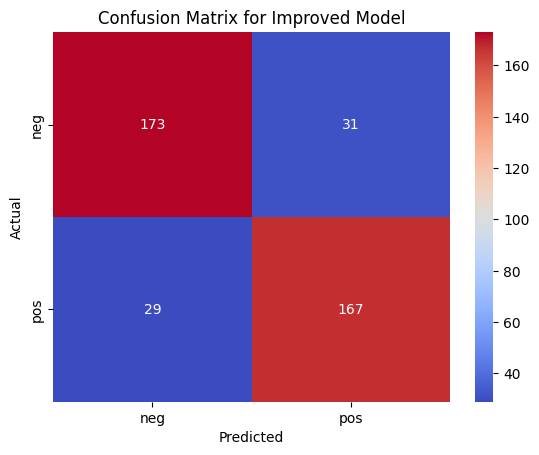

In [14]:
# Visualize the results for the improved model
cm = confusion_matrix(y_test, preds, labels=improved_model.classes_)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=improved_model.classes_, yticklabels=improved_model.classes_, cmap="coolwarm")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Improved Model')
plt.show()


Model Performance Table:
             Model  Precision  Recall  F1-Score  Train Time (s)
LogisticRegression   0.850065   0.850  0.850011        0.060321
      DecisionTree   0.654932   0.655  0.654819        0.867064
      RandomForest   0.804655   0.800  0.798887        0.838227
        NaiveBayes   0.845004   0.845  0.844981        0.002702

Training Time Comparison:


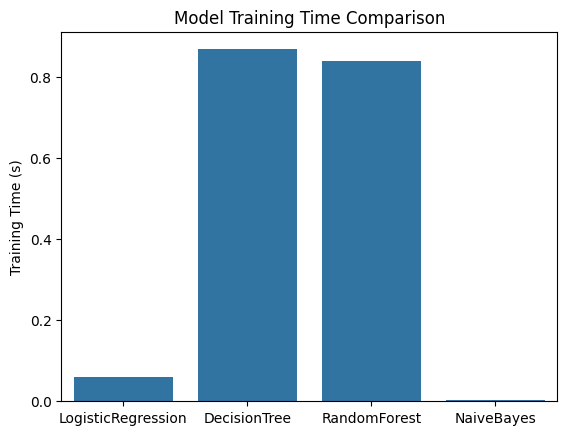

In [15]:
# Visualize the training time for each model
importances = []
times = []
names = []
metrics_table = []
for name, model in models.items():
    start = time.time()
    model.fit(X_train_vec, y_train)
    duration = time.time() - start
    times.append(duration)
    names.append(name)
    preds = model.predict(X_test_vec)
    precision, recall, f1, _ = precision_recall_fscore_support(y_test, preds, average='weighted')
    metrics_table.append([name, precision, recall, f1, duration])

print("\nModel Performance Table:")
metrics_df = pd.DataFrame(metrics_table, columns=['Model', 'Precision', 'Recall', 'F1-Score', 'Train Time (s)'])
print(metrics_df.to_string(index=False))
metrics_df.to_csv("model_performance_summary.csv", index=False)

print("\nTraining Time Comparison:")
sns.barplot(x=names, y=times)
plt.ylabel('Training Time (s)')
plt.title('Model Training Time Comparison')
plt.show()

### Extra Credit Option 2: Syntax-Based Feature Engineering
Develop a feature set that captures syntactic context, such as negation, using dependency parsing

In [16]:
import spacy
nlp = spacy.load("en_core_web_sm")

def extract_negation_features(docs):
    features = []
    for doc in docs:
        parsed = nlp(doc)
        negated_tokens = set()
        for token in parsed:
            if token.dep_ == "neg":
                head = token.head
                negated_tokens.add(head.lemma_)
        feature_dict = {tok.lemma_: 1 for tok in parsed if tok.lemma_ in negated_tokens}
        features.append(feature_dict)
    return features

from sklearn.feature_extraction import DictVectorizer

def evaluate_syntax_model(X_train, X_test, y_train, y_test):
    train_feats = extract_negation_features(X_train)
    test_feats = extract_negation_features(X_test)
    vec = DictVectorizer(sparse=True)
    X_train_vec = vec.fit_transform(train_feats)
    X_test_vec = vec.transform(test_feats)

    model = MultinomialNB()
    model.fit(X_train_vec, y_train)
    preds = model.predict(X_test_vec)
    print("\nSyntax-Aware Model Results:")
    print(classification_report(y_test, preds))

In [17]:
syntax_features = extract_negation_features(X_train)
print("\nCalling evaluate_syntax_model...")
evaluate_syntax_model(X_train, X_test, y_train, y_test)


Calling evaluate_syntax_model...

Syntax-Aware Model Results:
              precision    recall  f1-score   support

         neg       0.62      0.61      0.62       204
         pos       0.60      0.61      0.61       196

    accuracy                           0.61       400
   macro avg       0.61      0.61      0.61       400
weighted avg       0.61      0.61      0.61       400

